<a href="https://colab.research.google.com/github/Durga22-amie/-vqe-cancer-segmentation-/blob/main/Life_changer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dschettler8845_brats_2021_task1_path = kagglehub.dataset_download('dschettler8845/brats-2021-task1')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00495.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00621.tar


In [ ]:
import os

print(os.listdir('/kaggle/input/datasets'))

['dschettler8845']


In [ ]:
import os

print("Contents of /kaggle/input:")
print(os.listdir('/kaggle/input'))

Contents of /kaggle/input:
['datasets']


In [ ]:
import os

print("Contents of /kaggle/input/datasets:")
print(os.listdir('/kaggle/input/datasets'))

Contents of /kaggle/input/datasets:
['dschettler8845']


In [ ]:
import os

print(os.listdir('/kaggle/input/datasets/dschettler8845'))

['brats-2021-task1']


In [ ]:
import os

path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"

print("First 10 items:")
print(os.listdir(path)[:10])

First 10 items:
['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


In [ ]:
import os

path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"

for file in os.listdir(path):
    print(file)

BraTS2021_00495.tar
BraTS2021_Training_Data.tar
BraTS2021_00621.tar


In [ ]:
import tarfile
import os

tar_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"

extract_path = "/kaggle/working/BraTS2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path) as tar:
    tar.extractall(extract_path)

print("Extraction completed!")

/tmp/ipykernel_430/4020386247.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction completed!


In [ ]:
import os
print(len(os.listdir("/kaggle/working/BraTS2021")))

1252


In [ ]:
import os

print(os.listdir("/kaggle/working/BraTS2021")[:10])

['BraTS2021_00550', 'BraTS2021_00705', 'BraTS2021_01547', 'BraTS2021_01249', 'BraTS2021_00214', 'BraTS2021_00810', 'BraTS2021_01456', 'BraTS2021_00554', 'BraTS2021_01275', 'BraTS2021_01438']


In [ ]:
patient = os.listdir("/kaggle/working/BraTS2021")[0]

print(patient)

print(os.listdir(os.path.join("/kaggle/working/BraTS2021", patient)))

BraTS2021_00550
['BraTS2021_00550_seg.nii.gz', 'BraTS2021_00550_t1.nii.gz', 'BraTS2021_00550_t1ce.nii.gz', 'BraTS2021_00550_flair.nii.gz', 'BraTS2021_00550_t2.nii.gz']


In [ ]:
!pip install nibabel -q

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
patient_path = "/kaggle/working/BraTS2021/BraTS2021_00550"
print(os.listdir(patient_path))

['BraTS2021_00550_seg.nii.gz', 'BraTS2021_00550_t1.nii.gz', 'BraTS2021_00550_t1ce.nii.gz', 'BraTS2021_00550_flair.nii.gz', 'BraTS2021_00550_t2.nii.gz']


In [ ]:
flair = nib.load(os.path.join(patient_path,
                              "BraTS2021_00550_flair.nii.gz"))

flair_data = flair.get_fdata()

print(flair_data.shape)

(240, 240, 155)


In [ ]:
seg = nib.load(os.path.join(patient_path,
                            "BraTS2021_00550_seg.nii.gz"))

seg_data = seg.get_fdata()

print(seg_data.shape)

(240, 240, 155)


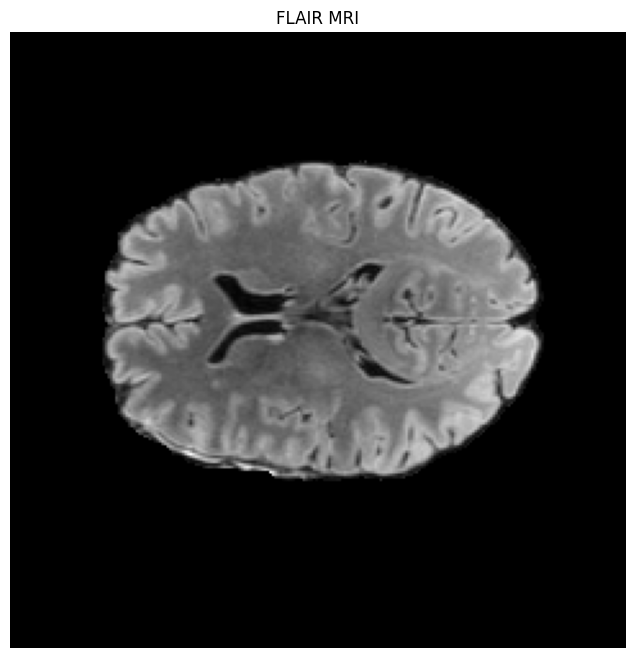

In [ ]:
slice_idx = flair_data.shape[2] // 2

plt.figure(figsize=(8,8))
plt.imshow(flair_data[:,:,slice_idx], cmap="gray")
plt.title("FLAIR MRI")
plt.axis("off")
plt.show()

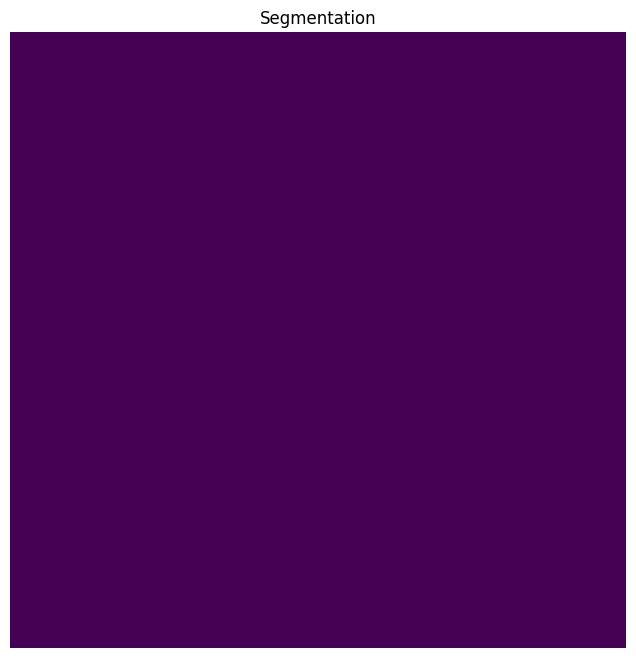

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(seg_data[:,:,slice_idx])
plt.title("Segmentation")
plt.axis("off")
plt.show()

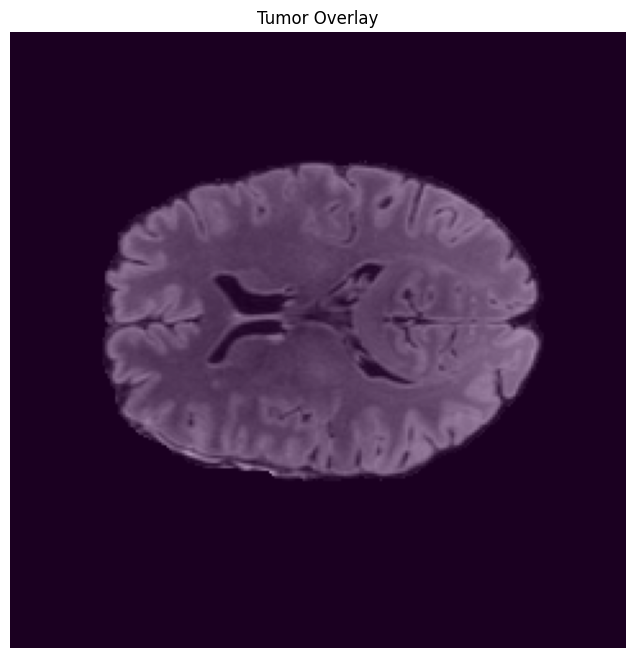

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(flair_data[:,:,slice_idx], cmap="gray")
plt.imshow(seg_data[:,:,slice_idx], alpha=0.4)
plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

In [ ]:
pip install --no-cache-dir SimpleITK

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm

ModuleNotFoundError: No module named 'radiomics'

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

In [ ]:
import skimage
print(skimage.__version__)

0.25.2


In [ ]:
import os

base_path = "/kaggle/working/BraTS2021"

patients = sorted(os.listdir(base_path))[:100]

print("Patients:", len(patients))
print(patients[:5])

Patients: 100
['.DS_Store', 'BraTS2021_00000', 'BraTS2021_00002', 'BraTS2021_00003', 'BraTS2021_00005']


In [ ]:
print("Patients:", len(patients))

Patients: 100


In [ ]:
import nibabel as nib
print(nib.__version__)

5.4.2


In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

In [ ]:
base_path = "/kaggle/working/BraTS2021"

patients = sorted(os.listdir(base_path))[:100]

print("Number of patients:", len(patients))
print("First patient:", patients[0])

Number of patients: 100
First patient: .DS_Store


In [ ]:
results = []

for patient in tqdm(patients):

    try:

        patient_path = os.path.join(base_path, patient)

        flair_path = os.path.join(
            patient_path,
            patient + "_flair.nii.gz"
        )

        seg_path = os.path.join(
            patient_path,
            patient + "_seg.nii.gz"
        )

        flair = nib.load(flair_path).get_fdata()
        seg = nib.load(seg_path).get_fdata()

        # Tumor voxels only
        tumor_pixels = flair[seg > 0]

        if len(tumor_pixels) < 10:
            continue

        # --------------------
        # First-order features
        # --------------------

        mean_val = np.mean(tumor_pixels)

        std_val = np.std(tumor_pixels)

        var_val = np.var(tumor_pixels)

        energy_val = np.sum(tumor_pixels ** 2)

        # Entropy
        hist, _ = np.histogram(
            tumor_pixels,
            bins=64,
            density=True
        )

        hist = hist[hist > 0]

        entropy_val = -np.sum(
            hist * np.log2(hist)
        )

        # --------------------
        # GLCM features
        # --------------------

        middle_slice = flair[:, :, flair.shape[2] // 2]

        middle_mask = seg[:, :, seg.shape[2] // 2]

        roi = middle_slice[middle_mask > 0]

        if len(roi) < 10:
            continue

        roi = roi.astype(np.float32)

        roi = (
            255
            * (roi - roi.min())
            / (roi.max() - roi.min() + 1e-8)
        )

        roi = roi.astype(np.uint8)

        side = int(np.sqrt(len(roi)))

        roi = roi[: side * side]

        roi = roi.reshape(side, side)

        glcm = graycomatrix(
            roi,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(
            glcm,
            "contrast"
        )[0, 0]

        correlation = graycoprops(
            glcm,
            "correlation"
        )[0, 0]

        homogeneity = graycoprops(
            glcm,
            "homogeneity"
        )[0, 0]

        dissimilarity = graycoprops(
            glcm,
            "dissimilarity"
        )[0, 0]

        asm = graycoprops(
            glcm,
            "ASM"
        )[0, 0]

        results.append({
            "Patient": patient,
            "Mean": mean_val,
            "Std": std_val,
            "Variance": var_val,
            "Energy": energy_val,
            "Entropy": entropy_val,
            "Contrast": contrast,
            "Correlation": correlation,
            "Homogeneity": homogeneity,
            "Dissimilarity": dissimilarity,
            "ASM": asm
        })

    except Exception as e:

        print(patient, e)

  0%|          | 0/100 [00:00<?, ?it/s]

.DS_Store No such file or no access: '/kaggle/working/BraTS2021/.DS_Store/.DS_Store_flair.nii.gz'


100%|██████████| 100/100 [00:25<00:00,  3.96it/s]


In [ ]:
df = pd.DataFrame(results)

print(df.shape)

df.head()

(92, 11)


,Patient,Mean,Std,Variance,Energy,Entropy,Contrast,Correlation,Homogeneity,Dissimilarity,ASM
0,BraTS2021_00000,1564.893779,353.633404,125056.584669,1.475002e+11,0.231704,332.184939,0.865871,0.088028,12.766334,0.000494
1,BraTS2021_00002,1333.553050,316.015256,99865.641857,3.579793e+11,0.264959,152.084265,0.963619,0.162813,7.858178,0.000438
2,BraTS2021_00003,1955.682514,385.049506,148263.122321,3.942723e+11,0.224307,6683.600000,0.192058,0.007410,57.200000,0.025000
3,BraTS2021_00005,2311.226914,401.889637,161515.279949,6.867164e+11,0.191391,735.862637,0.834899,0.037346,20.565934,0.002762
4,BraTS2021_00006,2746.294494,486.557267,236737.974109,1.072792e+12,0.205784,256.150689,0.932761,0.153968,9.314223,0.000515


In [ ]:
df.to_csv(
    "radiomics_100.csv",
    index=False
)

print("Saved radiomics_100.csv")

Saved radiomics_100.csv


In [ ]:
numeric_df = df.drop(
    columns=["Patient"]
)

variances = numeric_df.var()

top8 = variances.sort_values(
    ascending=False
).head(8)

print(top8)

Energy           1.056726e+23
Variance         1.082948e+10
Mean             6.216589e+05
Contrast         5.091287e+05
Std              3.046795e+04
Dissimilarity    4.031066e+01
Entropy          1.759659e-01
Correlation      9.176488e-03
dtype: float64


In [ ]:
top8_features = list(top8.index)

selected_df = df[
    ["Patient"] + top8_features
]

selected_df.head()

,Patient,Energy,Variance,Mean,Contrast,Std,Dissimilarity,Entropy,Correlation
0,BraTS2021_00000,1.475002e+11,125056.584669,1564.893779,332.184939,353.633404,12.766334,0.231704,0.865871
1,BraTS2021_00002,3.579793e+11,99865.641857,1333.553050,152.084265,316.015256,7.858178,0.264959,0.963619
2,BraTS2021_00003,3.942723e+11,148263.122321,1955.682514,6683.600000,385.049506,57.200000,0.224307,0.192058
3,BraTS2021_00005,6.867164e+11,161515.279949,2311.226914,735.862637,401.889637,20.565934,0.191391,0.834899
4,BraTS2021_00006,1.072792e+12,236737.974109,2746.294494,256.150689,486.557267,9.314223,0.205784,0.932761


In [ ]:
selected_df.to_csv(
    "top8_features.csv",
    index=False
)

print("Top 8 features saved.")

Top 8 features saved.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X = selected_df.drop(columns=["Patient"])

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

X_scaled[:5]

(92, 8)


array([[0.10885154, 0.31991819, 0.49917791, 0.03315023, 0.54191709,
        0.1091211 , 0.0488053 , 0.85020535],
       [0.26776477, 0.25484565, 0.41473916, 0.00573424, 0.47798232,
        0.01071434, 0.06673267, 0.97354164],
       [0.29516629, 0.37986466, 0.64181476, 1.        , 0.59531103,
        1.        , 0.04481813, 0.        ],
       [0.51596371, 0.41409726, 0.77158752, 0.09460042, 0.62393206,
        0.26550025, 0.02707318, 0.81112593],
       [0.8074535 , 0.6084104 , 0.93038602, 0.02157585, 0.76783083,
        0.03990752, 0.03483235, 0.93460595]])

In [ ]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.insert(
    0,
    "Patient",
    selected_df["Patient"].values
)

X_scaled_df.head()

,Patient,Energy,Variance,Mean,Contrast,Std,Dissimilarity,Entropy,Correlation
0,BraTS2021_00000,0.108852,0.319918,0.499178,0.033150,0.541917,0.109121,0.048805,0.850205
1,BraTS2021_00002,0.267765,0.254846,0.414739,0.005734,0.477982,0.010714,0.066733,0.973542
2,BraTS2021_00003,0.295166,0.379865,0.641815,1.000000,0.595311,1.000000,0.044818,0.000000
3,BraTS2021_00005,0.515964,0.414097,0.771588,0.094600,0.623932,0.265500,0.027073,0.811126
4,BraTS2021_00006,0.807454,0.608410,0.930386,0.021576,0.767831,0.039908,0.034832,0.934606


In [ ]:
X_scaled_df.to_csv(
    "normalized_top8.csv",
    index=False
)

print("Normalized features saved.")

Normalized features saved.


In [ ]:
!pip install qiskit qiskit-algorithms qiskit-aer -q

In [ ]:
import qiskit

print(qiskit.__version__)

2.4.1


In [ ]:
!pip install qiskit-algorithms -q

In [ ]:
import numpy as np
import pandas as pd

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes

from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA

In [ ]:
def create_hamiltonian(features):
    """
    features: array of length 8
    """

    paulis = []
    coeffs = []

    n_qubits = len(features)

    for i, value in enumerate(features):

        label = ['I'] * n_qubits

        label[i] = 'Z'

        paulis.append("".join(label))
        coeffs.append(float(value))

    return SparsePauliOp(paulis, coeffs)

In [ ]:
estimator = StatevectorEstimator()

optimizer = COBYLA(maxiter=100)

ansatz = RealAmplitudes(
    num_qubits=8,
    reps=2
)

print(ansatz)

     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
q_6: »
     »
q_7: »
     »
«     ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_1: ┤1                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_2: ┤2                                                                    

/tmp/ipykernel_430/3237301514.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


In [ ]:
first_patient = X_scaled[0]

H = create_hamiltonian(first_patient)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(H)

print("Ground-state energy:")
print(result.eigenvalue.real)

Ground-state energy:
-2.342415287443228


In [ ]:
vqe_energies = []

for i in range(len(X_scaled)):

    H = create_hamiltonian(X_scaled[i])

    try:
        vqe = VQE(
            estimator=estimator,
            ansatz=ansatz,
            optimizer=optimizer
        )

        result = vqe.compute_minimum_eigenvalue(H)

        energy = result.eigenvalue.real

    except Exception as e:

        print(i, e)

        energy = np.nan

    vqe_energies.append(energy)

In [ ]:
quantum_df = pd.DataFrame({
    "Patient": selected_df["Patient"],
    "VQE_Energy": vqe_energies
})

quantum_df.head()

,Patient,VQE_Energy
0,BraTS2021_00000,-2.345088
1,BraTS2021_00002,-2.308364
2,BraTS2021_00003,-3.105841
3,BraTS2021_00005,-3.148575
4,BraTS2021_00006,-3.771290


In [ ]:
quantum_df.to_csv(
    "quantum_biomarkers.csv",
    index=False
)

print("Saved quantum_biomarkers.csv")

Saved quantum_biomarkers.csv
